# 정기 예금 가입 예측 모델 개발

포르투갈 은행의 마케팅 데이터를 바탕으로,  
고객의 정기 예금 가입 여부(`y`)를 예측하는 분류 모델을 개발한다.  
실제 캠페인 적용을 염두에 두고, 다양한 전처리/샘플링/모델 조합을 실험하며  
전략 수립에 도움이 될 수 있는 인사이트 도출을 목표로 한다.

## 1. 데이터 구조 및 기본 탐색

- 데이터 크기 및 주요 변수 확인
- 변수 유형 구분 (수치형 / 범주형)


In [1]:
# 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import platform

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, precision_recall_curve

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings("ignore")

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False 


분석에 사용한 데이터는 포르투갈 은행의 마케팅 캠페인 기록으로,  
총 41,188개의 행과 21개의 열로 구성되어 있다.  
파일 형식은 CSV이며, 구분자는 세미콜론(`;`)으로 설정되어 있다.

### 1.1 데이터 크기 및 주요 변수 확인

In [2]:
# 데이터 불러오기
file_path = r'D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\raw\bank-additional-full.csv'
df = pd.read_csv(file_path, sep=';') 

# 기본 구조 확인
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

((41188, 21), None)

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.describe()

# 평균 나이는 약 40살

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [49]:
# 예금 가입률
deposit_col = 'deposit' if 'deposit' in df.columns else 'y'
deposit_rate = (df[deposit_col] == 'yes').mean() * 100
print(f"정기예금 가입률: {deposit_rate:.2f}%")

정기예금 가입률: 11.27%


수치형 변수 요약

- `duration`: 최대 4918초, 평균은 258초. → 분포 비대칭 가능성 높음
- `campaign`: 최대 56회. → 3회 이상은 이상치로 작용할 수도
- `pdays`: 대부분 999 → placeholder 값으로 추정됨 (이전 미접촉)

### 1.2 변수 유형 구분

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형과 범주형 변수 구분
cat_columns = df.select_dtypes(include='object').columns.tolist()
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 타깃 변수는 따로 관리
if 'deposit' in cat_columns:
    cat_columns.remove('deposit')

## 2. EDA 및 주요 변수 분석

- 수치형 변수 분포 및 이상치 확인
- 범주형 변수별 비율 및 전환율 시각화
- 주요 변수 간 상관관계 분석
- 타겟과의 관계 중심 변수 해석

### 2.1 수치형 변수

수치형 변수 탐색
- `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- histogram, kdeplot, boxplot, violinplot 등

---

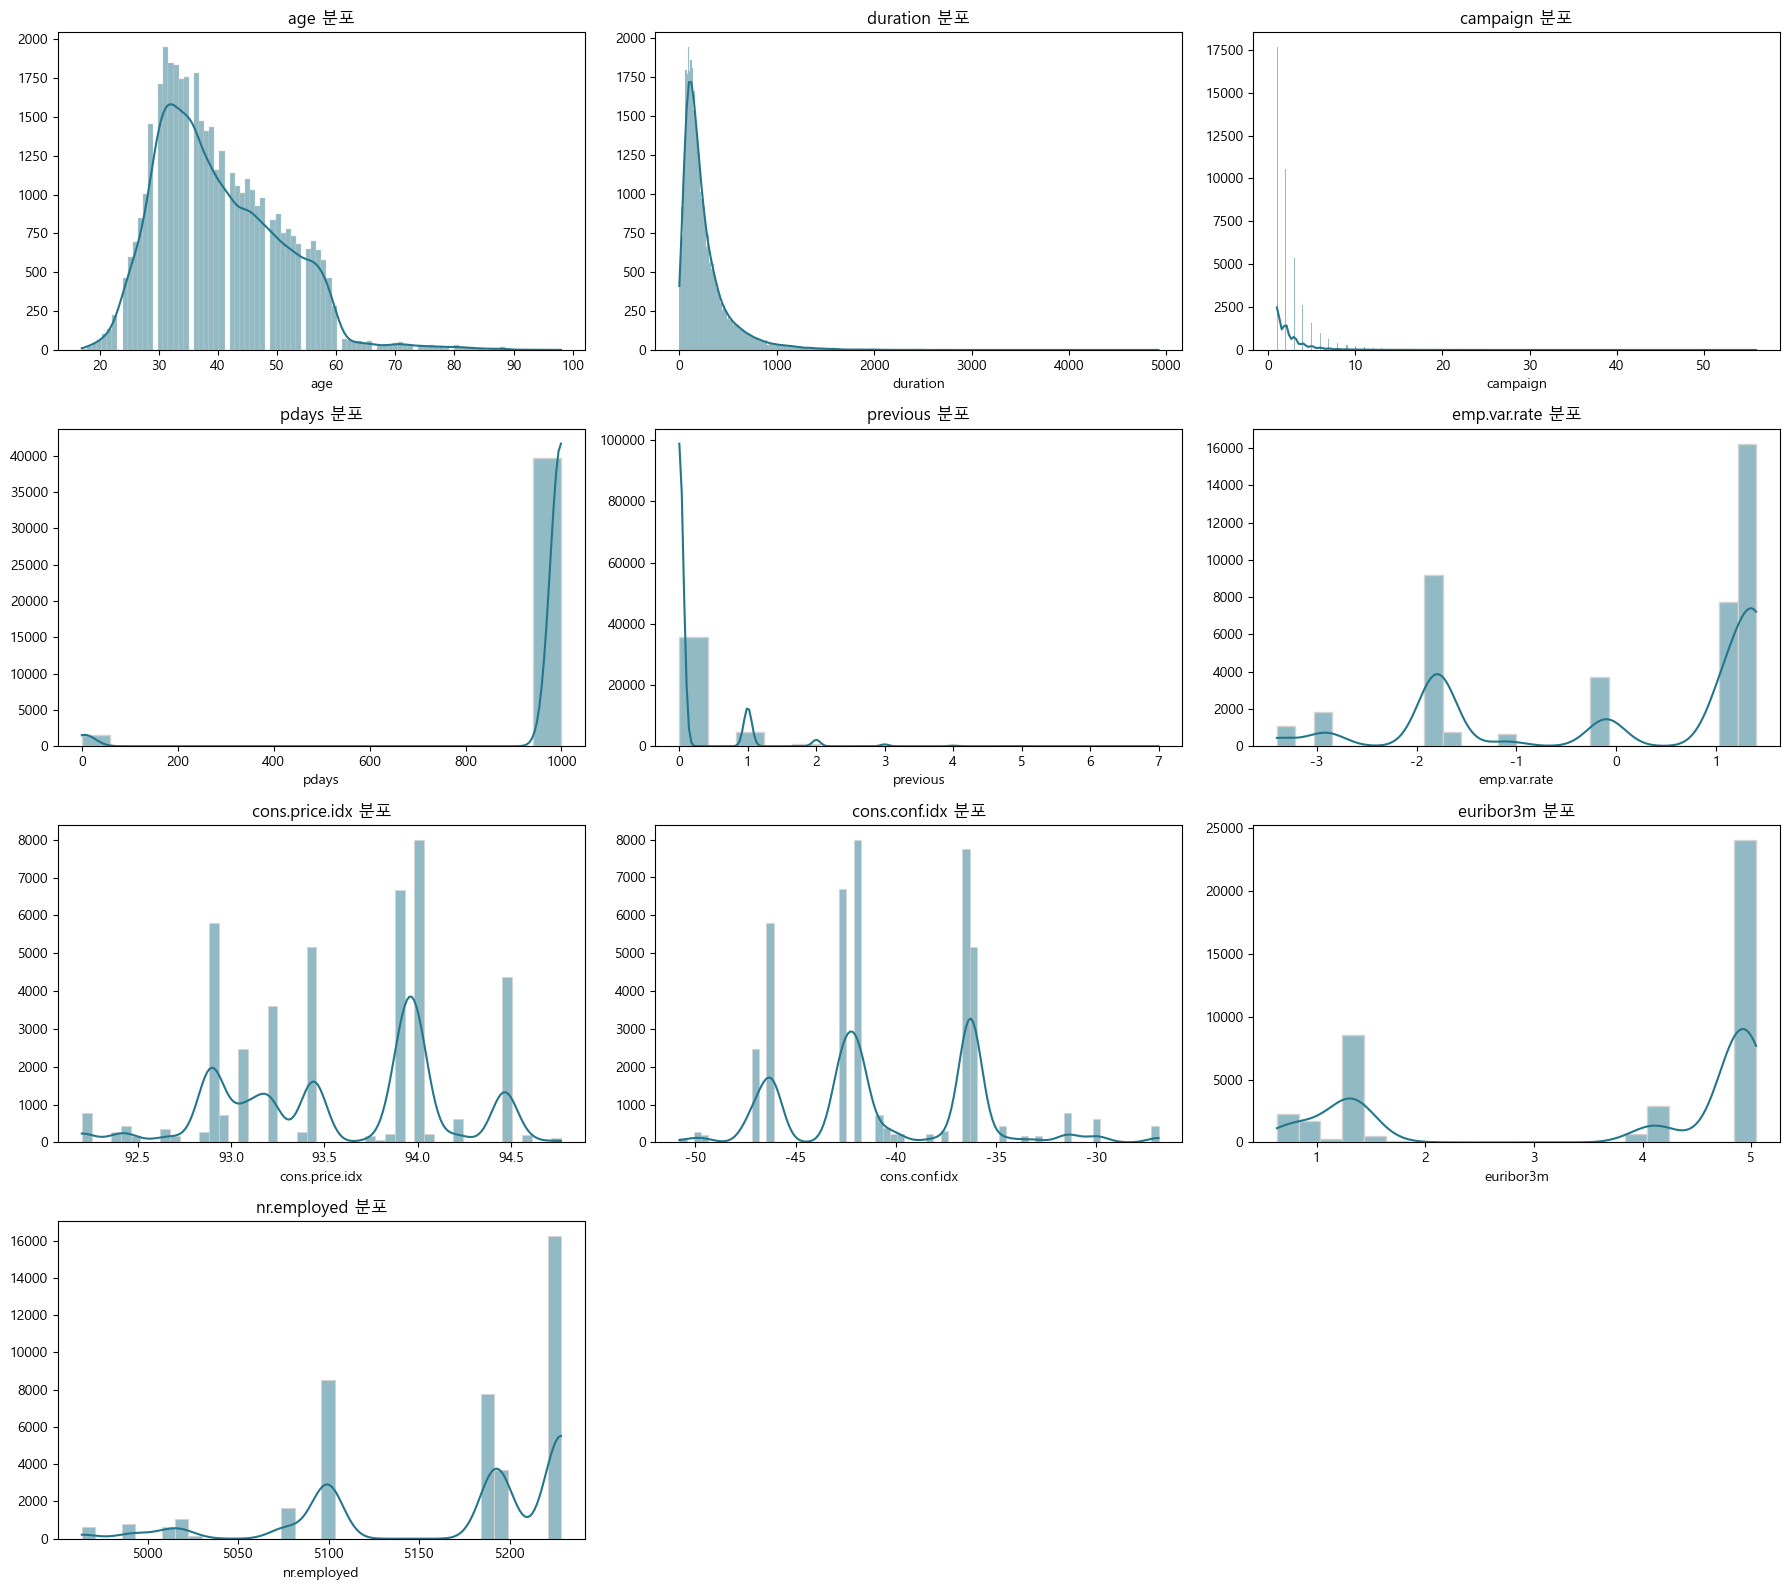

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 목록 재확인
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'deposit' in num_columns:
    num_columns.remove('deposit')

soft_palette = sns.color_palette("crest", as_cmap=True)

n_cols = 3
n_rows = -(-len(num_columns) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(num_columns):
    sns.histplot(data=df, x=col, kde=True, ax=axs[i], color=soft_palette(0.6), edgecolor='lightgray')
    axs[i].set_title(f'{col} 분포')
    axs[i].set_ylabel('')
    axs[i].tick_params(axis='x', rotation=0)

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


| 수치형 변수 분포 확인

기본 통계와 시각화를 통해 다음과 같은 특이사항이 확인되었다.

- `duration`: 대부분 500초 이하에 밀집. 분포 비대칭 심함 → 로그 변환 검토  
  다만, 사후 정보이므로 모델 학습에서는 제외할 가능성 높음

- `campaign`: 1~3회가 대부분이며, 30회 이상은 극단값 가능성 있음 → 상한값 설정 고려

- `pdays`: 거의 대부분이 999 → 이전 캠페인 미접촉을 의미하는 특수값으로 해석됨  
  → `was_contacted_before` 파생 변수 생성 예정

- `previous`: 0이 대부분, 일부 고객만 이전 캠페인 이력 보유 → 이진 변수화 가능

- `age`: 전반적으로 자연스러운 분포. 30~40대 비중이 가장 큼

- 거시경제 변수(`emp.var.rate`, `euribor3m` 등): 이산값 위주로 구성되어 있어 정규성 부족  
  → 로그 또는 스케일 조정 고려 필요

→ 우선 분포 왜곡이 심한 변수들을 중심으로 변환 및 파생 변수 설계를 진행하고자 한다.

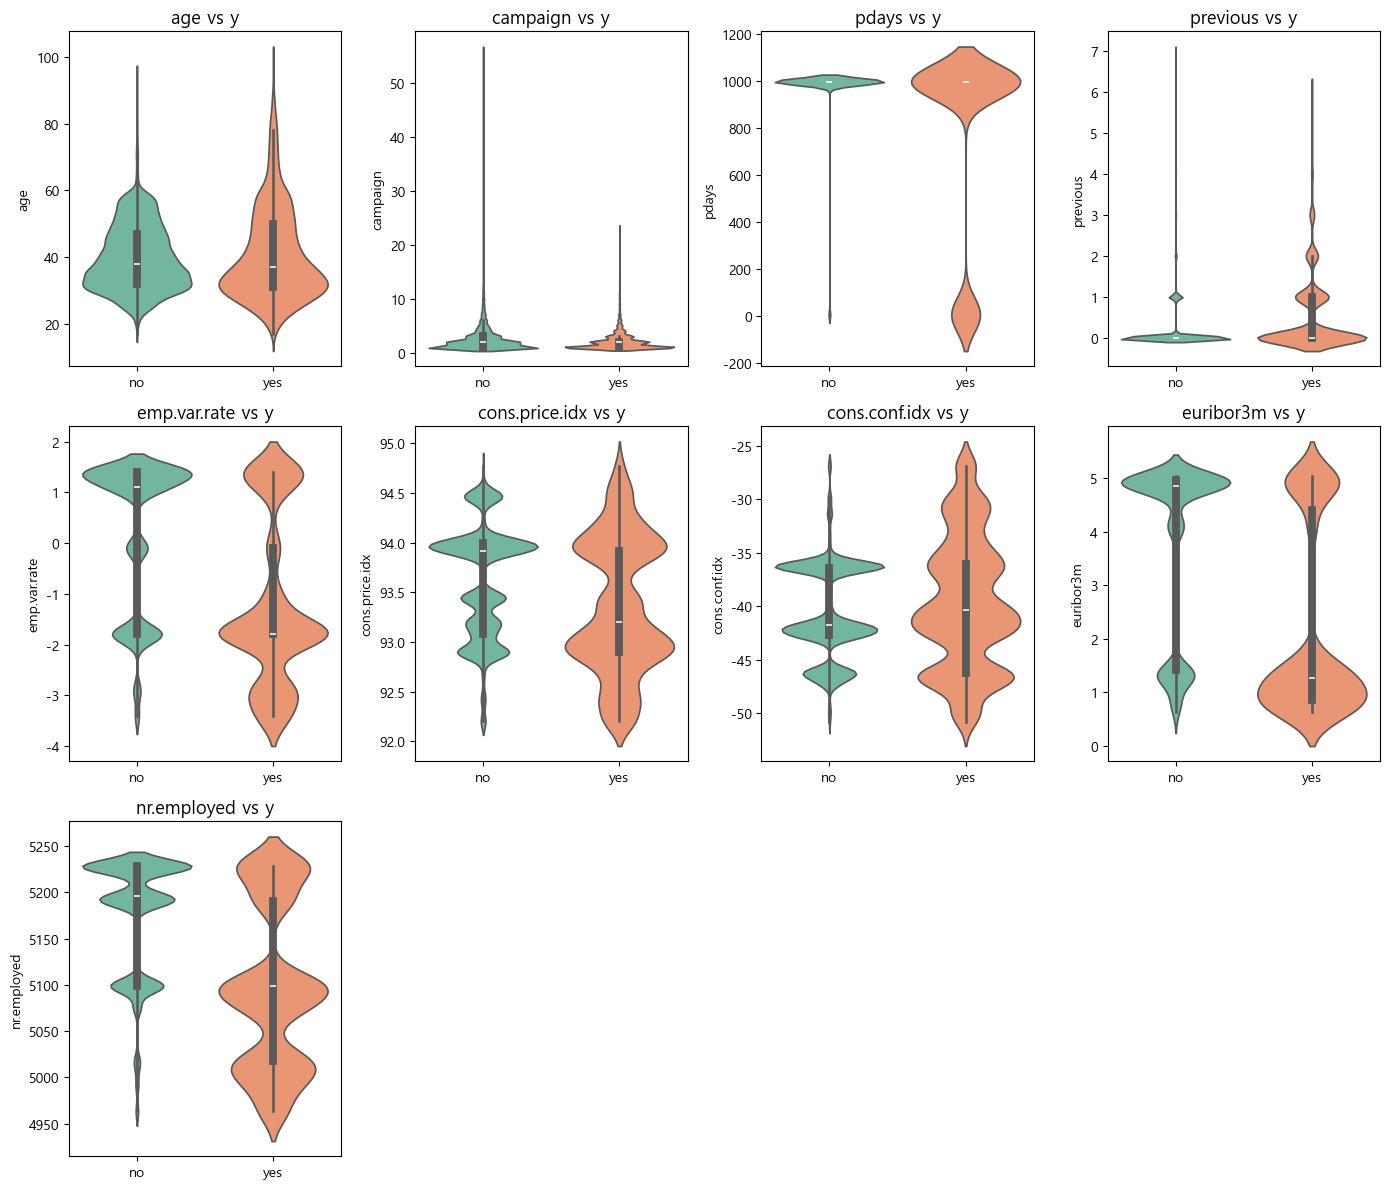

In [9]:
# 수치형 변수 목록
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'duration' in num_cols:  # duration은 예측 변수에서 제외 예정이나 지금은 포함
    num_cols.remove('duration')  # 필요시 제거
if 'deposit' in num_cols or 'y' in num_cols:
    num_cols = [c for c in num_cols if c not in ['deposit', 'y']]

# soft 색상 설정
soft_palette = sns.color_palette("Set2")

# boxplot 시각화
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='y', y=col, ax=axs[i], palette=soft_palette)
    axs[i].set_title(f"{col} vs y", fontsize=13)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(col)

# 빈 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


타겟 변수(`deposit`) 기준으로 수치형 변수들의 분포를 비교한 결과,  
다음과 같은 패턴과 전처리 포인트가 확인되었다.

이상치
- `campaign`: 40~50회 이상 값은 전환율과 무관하게 분포가 극단적으로 치우침 → 명백한 이상치
- `pdays`: 1000에 수렴하는 값이 대다수 → 이전 미접촉을 의미하는 특별값으로 별도 처리 필요
- `age`: 분포상 자연스럽고, 하한도 18세 이상으로 설정되어 있어 이상치는 없음

전처리
- `campaign`: 상한값 제한 필요 (`min(x, 30)` 등으로 클리핑 처리)
- `pdays`: `999` 여부를 기준으로 `was_contacted_before` 이진 변수 생성
- `previous`: 0 vs 1 이상으로 이진화 → `had_previous_contact` 변수 생성 가능
- `age`: 구간화(`age_group`) 또는 고령 여부 이진 변수로도 활용 가능
- `euribor3m`: 중요 변수로 유지하되, 변동성 큰 구간 중심으로 나누는 것도 고려 가능

→ 위 전처리 아이디어는 이후 모델링 실험에 따라 수정될 수 있으므로,  
   다양한 버전으로 시도하며 영향도 평가를 해볼 생각이다..


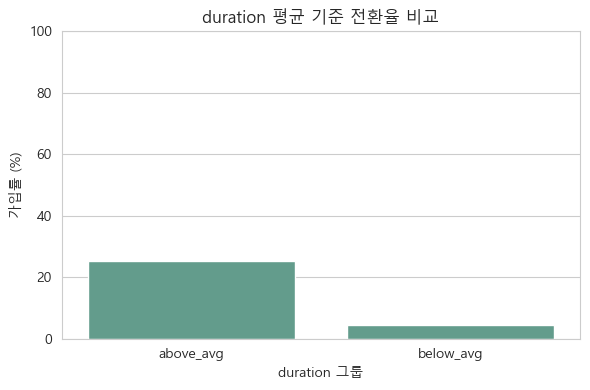

In [45]:
### 1. duration 분석 (전환율 관점)
avg_duration = df['duration'].mean()
df['duration_group'] = df['duration'].apply(lambda x: 'above_avg' if x > avg_duration else 'below_avg')

duration_ratio = pd.crosstab(df['duration_group'], df['y'], normalize='index') * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=duration_ratio.index, y=duration_ratio['yes'], color=palette_color)
plt.title("duration 평균 기준 전환율 비교")
plt.ylabel("가입률 (%)")
plt.xlabel("duration 그룹")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

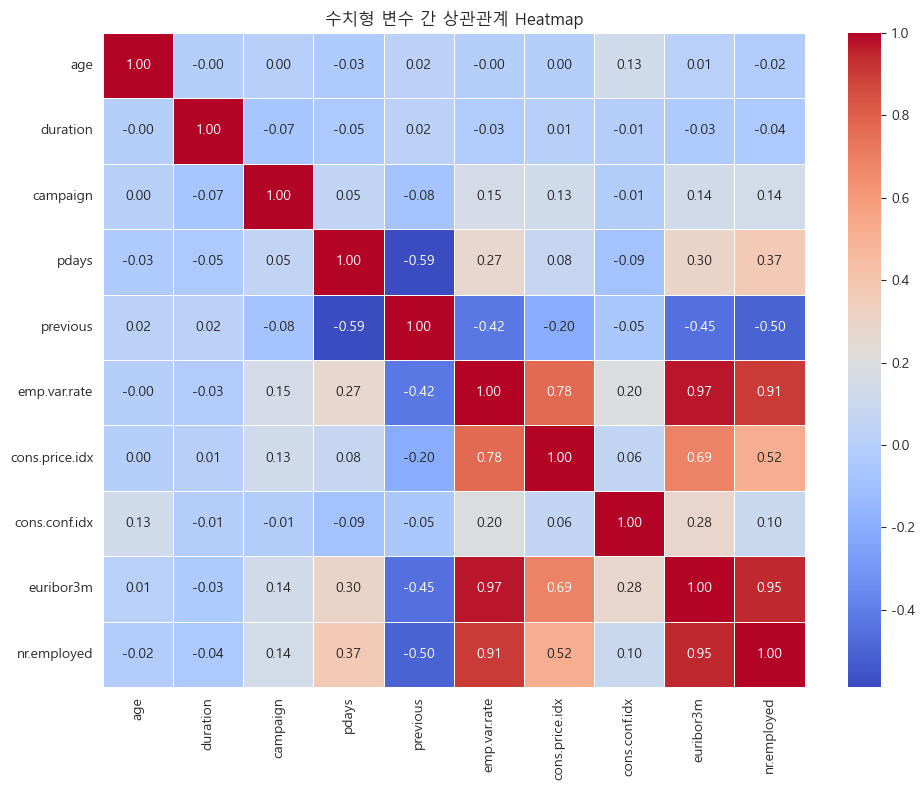

In [46]:
### 2. 수치형 변수 상관관계 heatmap
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['deposit']]  # y 제외

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("수치형 변수 간 상관관계 Heatmap")
plt.tight_layout()
plt.show()


 수치형 변수 간 상관관계 분석

상관계수 히트맵을 통해 확인한 결과, 다음과 같은 변수 간 강한 상관관계가 나타났다.

- `euribor3m`, `emp.var.rate`, `nr.employed`: **0.9 이상**의 강한 양의 상관관계  
  → 유사한 거시경제 지표로 해석되며, 다중 공선성 주의 필요

- `pdays`, `previous`: -0.59 수준의 음의 상관관계  
  → 과거 연락 여부가 반영된 구조적 관계로 판단됨

나머지 주요 변수들 간에는 뚜렷한 상관관계 없이 비교적 독립적인 분포를 보였다.

→ 이후 모델링 시, `euribor3m` 중심으로 한 변수 선택 또는 로그 변환 조합을 우선 고려하면 좋을 듯 싶다.


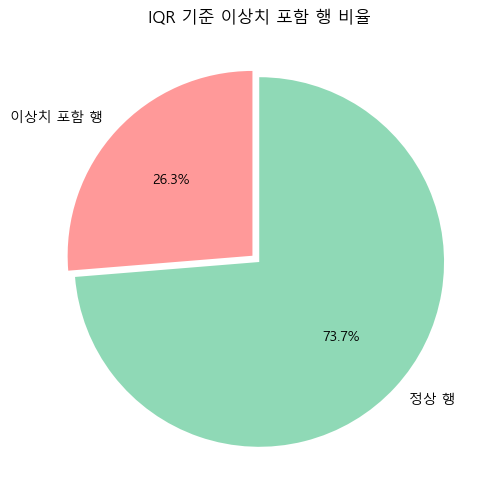

이상치 포함 행: 10828 / 전체: 41188 (26.29%)


In [10]:
# IQR 기반 이상치가 하나라도 포함된 행의 비율 파이차트로 시각화

# 이상치 마스크 생성 (각 열별)
outlier_mask_df = pd.DataFrame(False, index=df.index, columns=num_columns)
for col in num_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask_df[col] = (df[col] < lower) | (df[col] > upper)

# 이상치가 하나라도 있는 행
outlier_row_mask = outlier_mask_df.any(axis=1)
n_outlier_rows = outlier_row_mask.sum()
n_total = len(df)

# 파이차트 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(
    [n_outlier_rows, n_total - n_outlier_rows],
    labels=['이상치 포함 행', '정상 행'],
    autopct='%1.1f%%',
    colors=['#ff9999', '#8fd9b6'],
    startangle=90,
    explode=(0.05, 0)
)
plt.title('IQR 기준 이상치 포함 행 비율')
plt.show()

print(f"이상치 포함 행: {n_outlier_rows} / 전체: {n_total} ({n_outlier_rows/n_total:.2%})")

| IQR 기반 이상치 탐지 결과 요약

수치형 변수에 대해 IQR 기준으로 이상치를 탐지해본 결과,  
전체 데이터 중 약 26% 이상이 하나 이상의 변수에서 이상치를 포함하고 있었다.  
이 중 실제 모델링에 영향을 줄 수 있는 변수들을 중심으로 우선 정리하였다.

| 변수명        | 이상치 수 | 비율     | 처리 방향 요약 |
|---------------|-----------|----------|-----------------|
| `previous`     | 5,625     | 13.66%   | 대부분 0 → 1 이상 여부로 이진화 예정 |
| `duration`     | 2,963     | 7.19%    | 사후 정보 → 컬럼 자체 삭제 예정 |
| `campaign`     | 2,406     | 5.84%    | 30 이상 값 제거 또는 상한값 지정 예정 |
| `pdays`        | 1,515     | 3.67%    | `999` 여부 기준 이진 변수화 예정 |
| `age`          | 469       | 1.14%    | 분포 자연스러움 → 제거 없이 유지 |
| `cons.conf.idx`| 447       | 1.09%    | 로그 변환 등으로 왜도 조정 예정 |

나머지 변수들(`emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`)에서는  
IQR 기준 이상치가 발견되지 않았다.

→ `duration`, `campaign`, `previous`는 전처리 전략에 핵심적으로 반영될 예정이며,  
   이진화 여부와 이상치 제거 효과는 모델 성능 비교로 확인할 계획.


### 2.2 범주형 변수

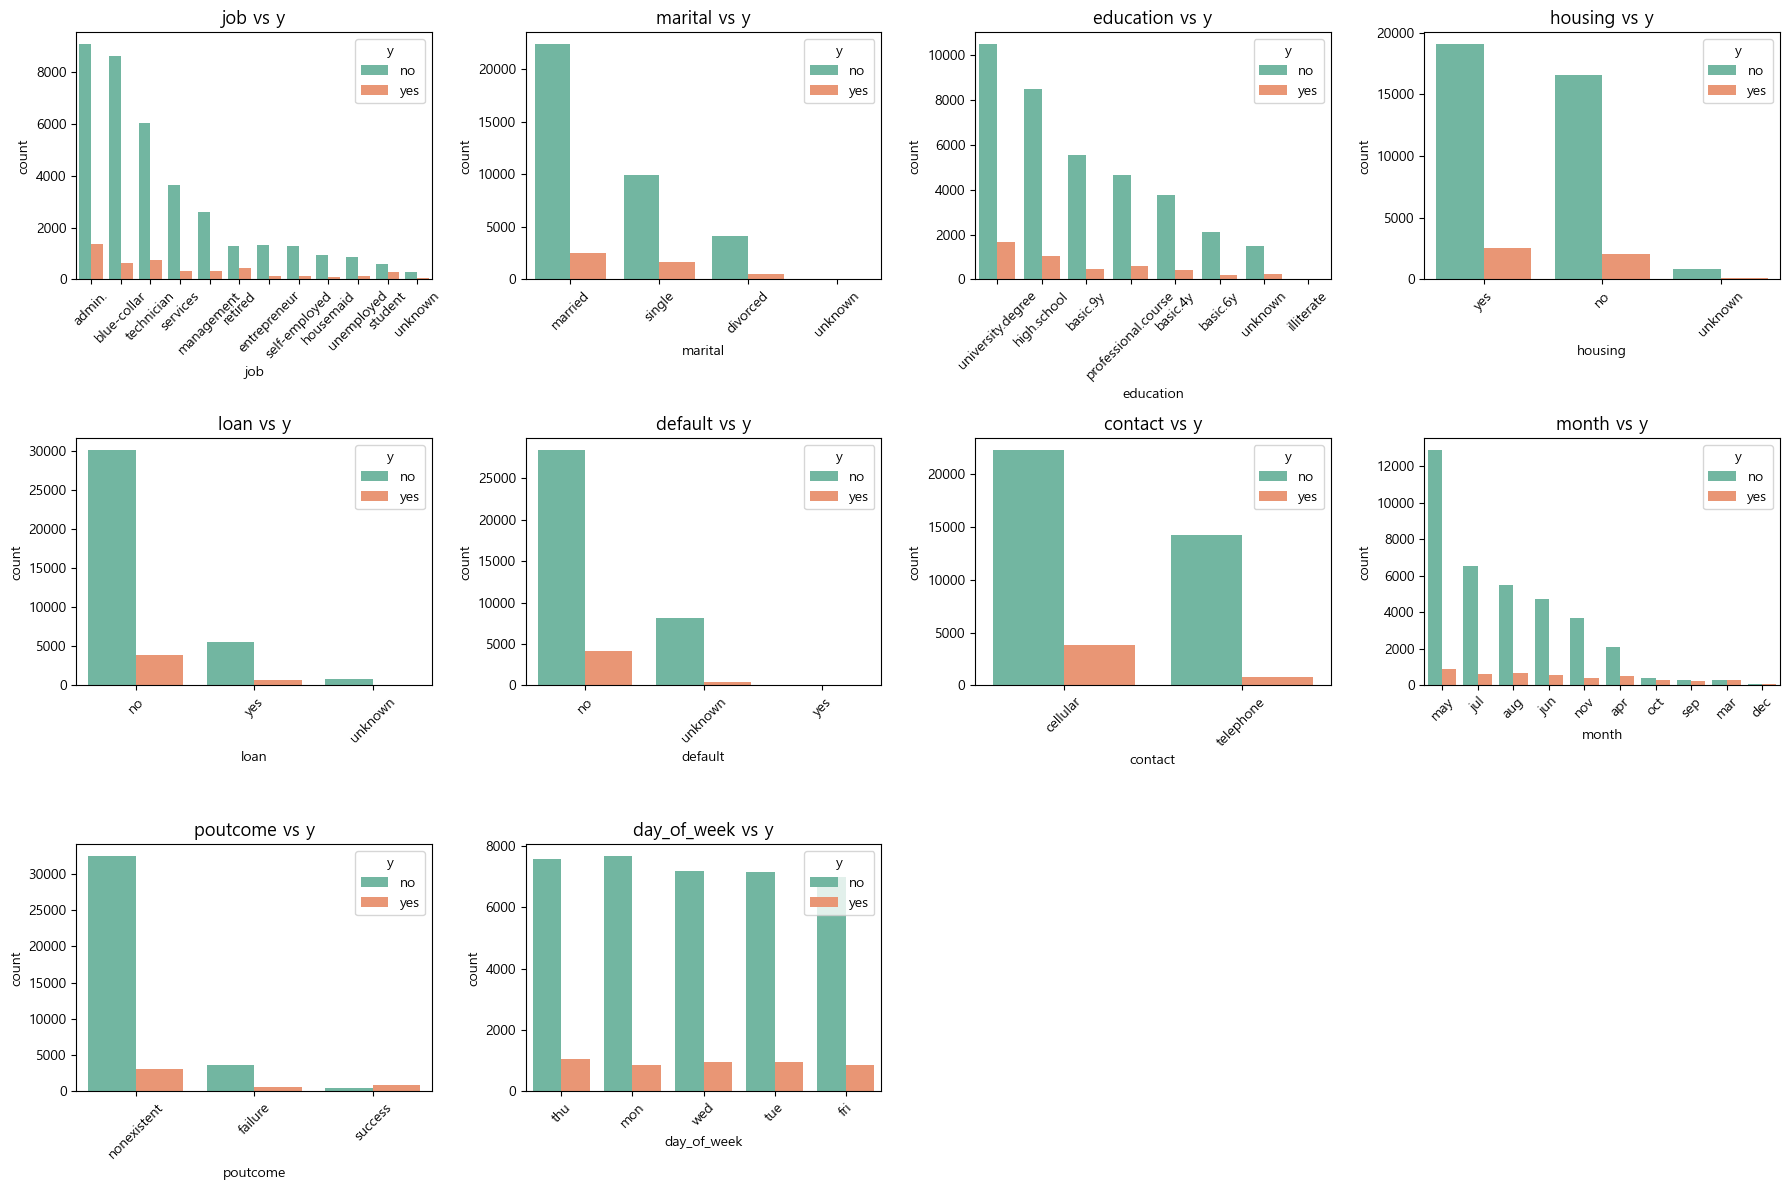

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 확인할 주요 범주형 변수 리스트
cat_cols = [
    'job', 'marital', 'education',
    'housing', 'loan', 'default',
    'contact', 'month', 'poutcome', 'day_of_week'
]

soft_color = sns.color_palette("flare")[2]

n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, x=col, hue='y', ax=axs[i],
        palette=sns.color_palette("Set2"),
        order=df[col].value_counts().index
    )
    axs[i].set_title(f"{col} vs y", fontsize=13)
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].set_ylabel("count")

# 남는 subplot 제거
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

범주형 변수의 `y` 분포 비교

범주형 변수별로 예금 가입 여부(`y`)에 따른 분포 차이를 시각화하여 확인했다.  
몇 가지 눈에 띄는 특이점은 다음과 같다.

- `job`: `student`, `retired`, `unemployed` 그룹에서 상대적으로 높은 전환율.  
  → 인원 수는 적지만 전환율 기준으로는 핵심 타겟이 될 수 있음

- `month`: `may`에 데이터가 집중되어 있으나, 전환율은 낮은 편  
  반면 `mar`, `dec`는 수는 적지만 전환율이 높음 → 시기별 효과 차이 존재

- `contact`: 대부분 `cellular`, 하지만 `telephone`이 의외로 높은 비율 유지  
  → 수단별 응답 특성에 차이 가능성 있음

- `poutcome`: `success`가 극히 적은 비율이지만, 가입 비율은 매우 높음  
  → 이전 캠페인 성공 이력은 강한 예측 신호

- `default`, `loan`, `housing`: `unknown` 비율이 높은 경우 있음  
  → 전처리 시 이진화 또는 희소 범주 통합 처리 필요

→ 범주형 변수 다수가 `y`와 뚜렷한 연관을 보이며,  
   전처리 및 인코딩 방식에 따라 예측력이 달라질 수 있는 지점들로 판단된다.


In [ ]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기준)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

cat_cols = [
    'job', 'marital', 'education',
    'housing', 'loan', 'default',
    'contact', 'month', 'poutcome',
    'day_of_week'
]

import plotly.graph_objects as go

# fig.update_layout(font=dict(family="Malgun Gothic"))

# 시각화 스타일
palette_color = sns.color_palette("crest")[1]
sns.set_style("whitegrid")

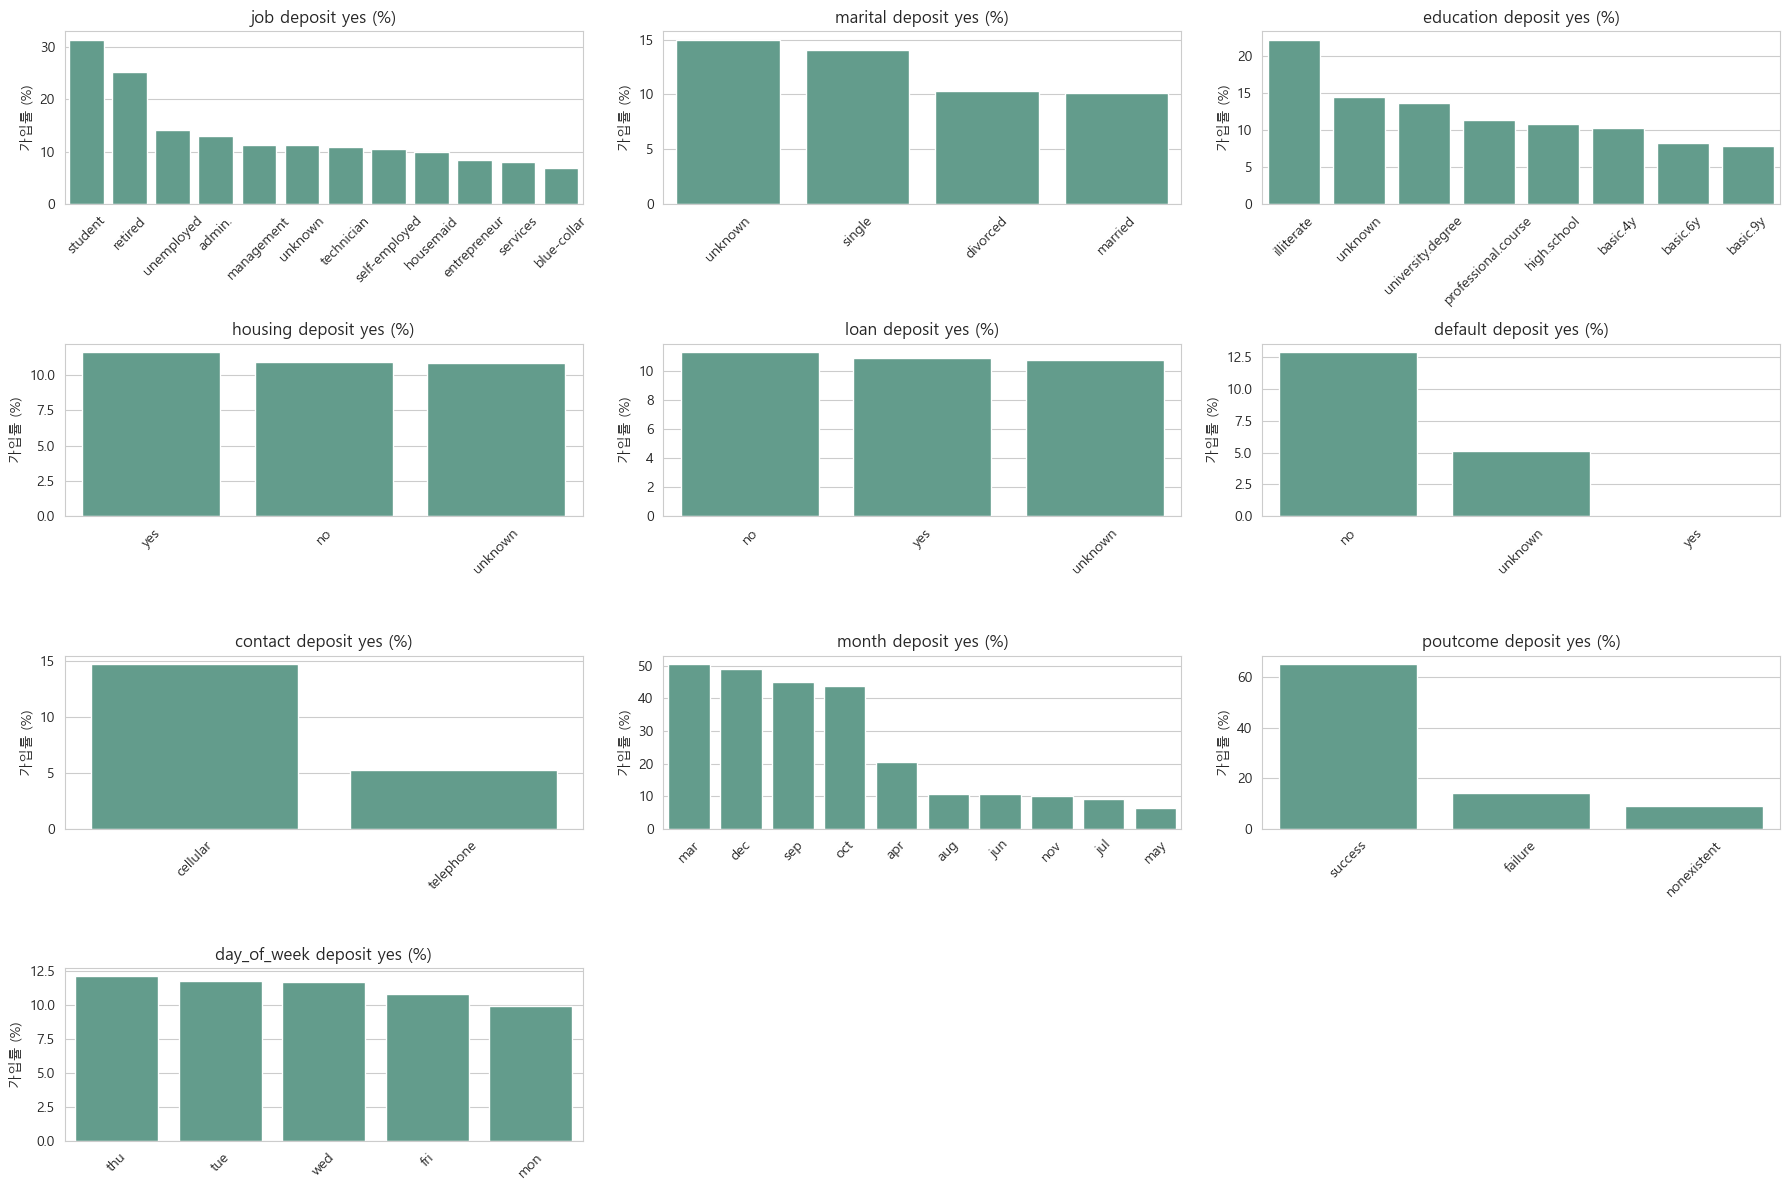

In [42]:
# -------- 1. 전환율 (deposit = yes 비율) 시각화 --------
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    rate = pd.crosstab(df[col], df['y'], normalize='index') * 100
    rate = rate['yes'].sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, color=palette_color, ax=axs[i])
    axs[i].set_title(f"{col} deposit yes (%)")
    axs[i].set_ylabel("가입률 (%)")
    axs[i].set_xlabel("")
    axs[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

범주형 변수별 예금 가입 전환율 비교 (`y = yes` 비율)

범주형 변수별로 예금 가입률(전환율)을 계산하여 시각화해보았다.  
단순 분포와는 다른 패턴들이 다수 확인되었다.

- `job`: `student`, `retired`, `unemployed` 그룹의 전환율이 20% 이상으로 높게 나타남  
  → 전체 수는 적지만 전환 성향이 뚜렷한 핵심 세그먼트

- `education`: `illiterate`, `unknown` 그룹에서 오히려 전환율이 높음  
  → 통상적 기대와 다르며, 변수 자체의 해석보다 다른 요인과의 결합 가능성 고려 필요

- `month`: `mar`, `dec`, `sep` 등 캠페인 규모는 작지만 전환율은 높게 나타남  
  → 캠페인 시점별 효율 편차 존재. `may`는 데이터량은 많지만 전환율은 최하위

- `poutcome`: `success`일 경우 전환율이 60% 이상으로 압도적으로 높음  
  → 과거 캠페인 반응 이력이 강한 예측 요인임을 다시 확인

- `contact`: `cellular`이 `telephone`에 비해 전환율에서 확실한 우위를 가짐  
  → 고객군 특성 또는 연락 수단의 심리적 수용성 차이로 해석 가능

→ 단순 빈도보다 전환율 기준으로 의미 있는 변수들이 드러나며,  
   이후 피처 선택과 타겟 세분화 전략에 적극 활용될 수 있다.


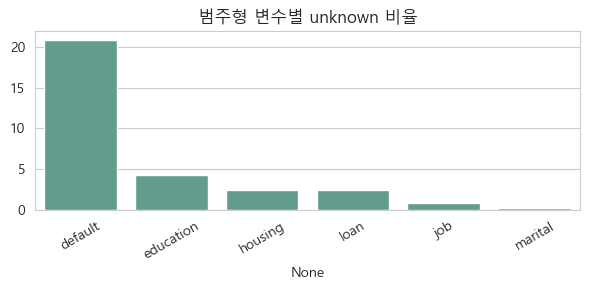

In [43]:
# -------- 2. unknown 비율 요약 (표 형태로 출력) --------
unknown_summary = {}
for col in cat_cols:
    if 'unknown' in df[col].unique():
        pct = (df[col] == 'unknown').mean() * 100
        unknown_summary[col] = round(pct, 2)

unknown_df = pd.Series(unknown_summary).sort_values(ascending=False).rename("unknown 비율 (%)").to_frame()

plt.figure(figsize=(6, 3))
sns.barplot(
    x=unknown_df.index,
    y=unknown_df["unknown 비율 (%)"].values,
    color=palette_color
)
plt.title("범주형 변수별 unknown 비율")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


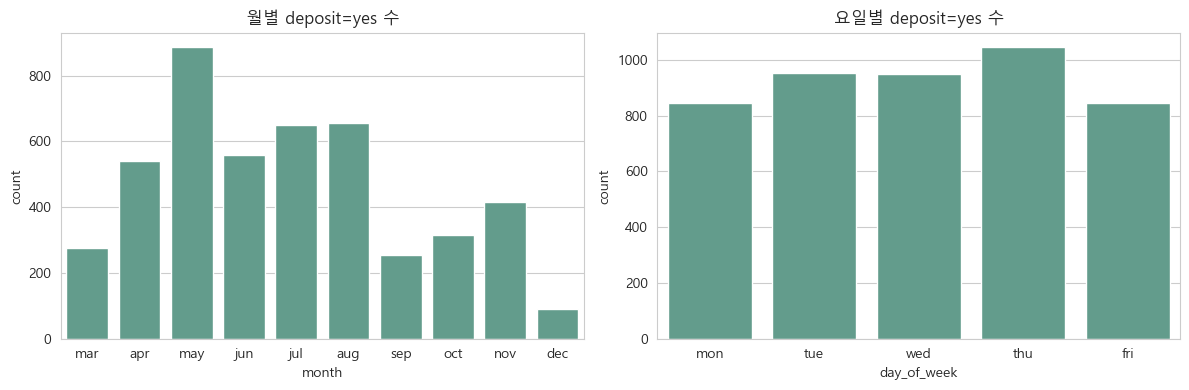

In [44]:
# -------- 3. 시기성 분석: month, day_of_week --------
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
dow_order = ['mon','tue','wed','thu','fri']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df[df['y'] == 'yes'], x='month', order=month_order, color=palette_color, ax=axes[0])
axes[0].set_title("월별 deposit=yes 수")

sns.countplot(data=df[df['y'] == 'yes'], x='day_of_week', order=dow_order, color=palette_color, ax=axes[1])
axes[1].set_title("요일별 deposit=yes 수")

plt.tight_layout()
plt.show()

범주형 변수 분석 요약

- `job`: `student`, `retired`, `unemployed`의 가입률이 높고, `blue-collar`, `entrepreneur`는 낮은 편
- `marital`: `single`과 `unknown`이 상대적으로 높고, `married`는 가장 낮음
- `education`: `illiterate`, `unknown` 전환율은 높지만 표본 수가 적어 해석 유의
- `contact`: `cellular`이 `telephone`보다 전환율 우위
- `month`: `mar`, `dec`, `sep` 등은 소규모지만 전환율 높음. `may`는 반대로 낮음
- `poutcome`: `success`일 경우 전환율 60% 이상으로 압도적

---

 `unknown` 값 처리 검토

- `default`: `unknown` 비율 약 21% → 제거 또는 `has_info` 변수로 전환 고려
- `education`, `housing`, `loan`: 2~4% 수준으로 보완 가능
- `job`, `marital`: 안정적, 별도 처리 불필요

---

마케팅 시기 관련 특이사항

- `month`: **5월**은 캠페인량 대비 성과 낮음, 반대로 **3월**, **12월**은 전환 효율 높음
- `day_of_week`: `thu` 비중이 가장 높고, `mon`, `fri`는 다소 낮음  
  → 다만 요일 간 차이는 전체적으로 크지 않음


### 2.3 기타

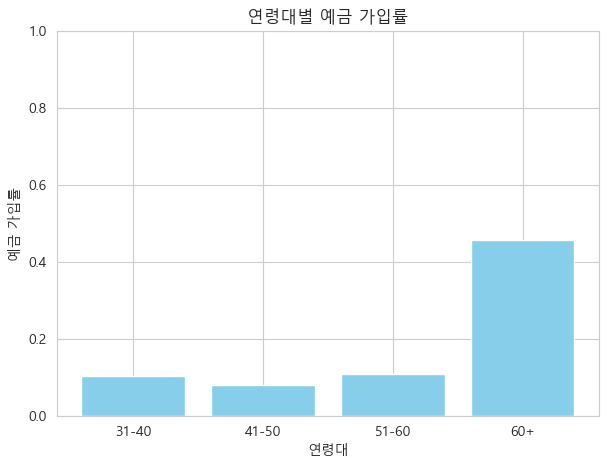

In [65]:
import matplotlib.pyplot as plt

# 1. 연령대별 예금 가입률 비교 그래프
age_groups = ['age_group_31-40', 'age_group_41-50', 'age_group_51-60', 'age_group_60+']
age_labels = ['31-40', '41-50', '51-60', '60+']

# 각 연령대별 가입률 계산
age_rates = []
for col in age_groups:
    mask = X_test[col]
    if mask.sum() > 0:
        rate = y_test[mask].mean()
    else:
        rate = 0
    age_rates.append(rate)

plt.figure(figsize=(7, 5))
plt.bar(age_labels, age_rates, color='skyblue')
plt.ylabel('예금 가입률')
plt.xlabel('연령대')
plt.title('연령대별 예금 가입률')
plt.ylim(0, 1)
plt.show()

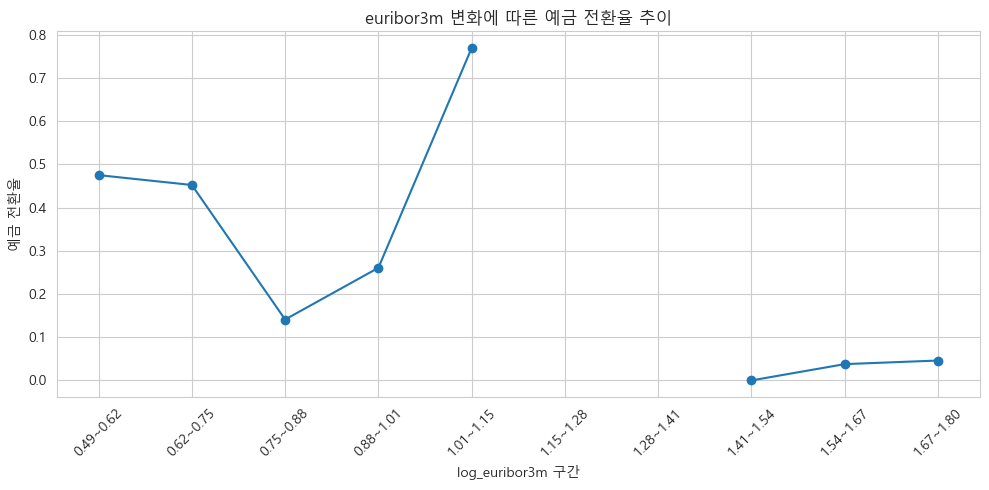

In [66]:
import numpy as np

import matplotlib.pyplot as plt

# 구간 나누기 (예: 10개 구간)
euribor_col = 'log_euribor3m'
n_bins = 10
euribor_values = X_test[euribor_col]
bins = np.linspace(euribor_values.min(), euribor_values.max(), n_bins + 1)
labels = [f"{bins[i]:.2f}~{bins[i+1]:.2f}" for i in range(n_bins)]
euribor_bin = pd.cut(euribor_values, bins=bins, labels=labels, include_lowest=True)

# 각 구간별 예금 전환율 계산
conversion_rates = y_test.groupby(euribor_bin).mean()

plt.figure(figsize=(10, 5))
plt.plot(labels, conversion_rates, marker='o')
plt.xlabel('log_euribor3m 구간')
plt.ylabel('예금 전환율')
plt.title('euribor3m 변화에 따른 예금 전환율 추이')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

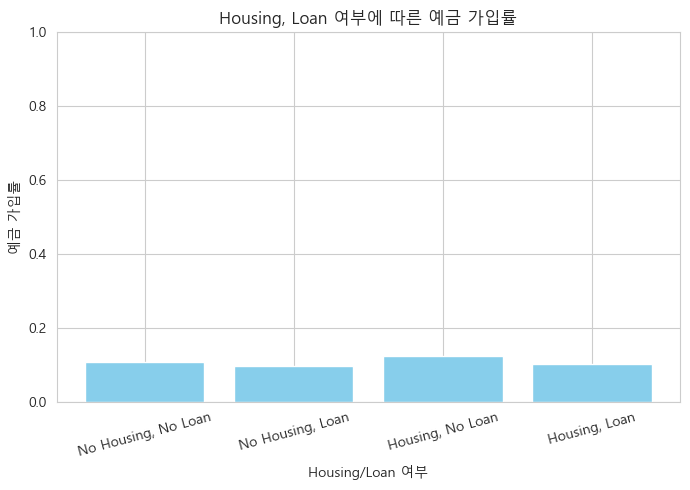

In [67]:
import matplotlib.pyplot as plt

# housing, loan 조합별 가입률 계산
group_cols = ['housing_yes', 'loan_yes']
group_labels = {
    (False, False): 'No Housing, No Loan',
    (False, True): 'No Housing, Loan',
    (True, False): 'Housing, No Loan',
    (True, True): 'Housing, Loan'
}

# X_test와 y_test를 합쳐서 분석
df_test = X_test.copy()
df_test['y'] = y_test.values

# 조합별 가입률
rates = []
labels = []
for h in [False, True]:
    for l in [False, True]:
        mask = (df_test['housing_yes'] == h) & (df_test['loan_yes'] == l)
        rate = df_test.loc[mask, 'y'].mean() if mask.sum() > 0 else 0
        rates.append(rate)
        labels.append(group_labels[(h, l)])

plt.figure(figsize=(7, 5))
plt.bar(labels, rates, color='skyblue')
plt.ylabel('예금 가입률')
plt.xlabel('Housing/Loan 여부')
plt.title('Housing, Loan 여부에 따른 예금 가입률')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. 전처리 및 피처 엔지니어링

EDA 이후, 최종적으로 변수를 아래와 같이 정리하였다.



### 3.1전처리 요약

| 변수명         | 타입   | 설명                    | 시각화 기반 특성 요약                                         | 전처리 및 파생 변수 처리 요약                                |
|----------------|--------|-------------------------|--------------------------------------------------|---------------------------------------------------|
| age            | 수치형 | 나이                    | 고령층(60+) 전환율 높음, 젊은 층(≤30) 낮음                     | `log_age` 생성, `age_group` 구간화 파생 변수 생성        |
| job            | 범주형 | 직업                    | `student`, `retired` 전환율 높음. 희소 직군 존재               | 희소 범주 `'rare'`로 통합 후 one-hot 인코딩             |
| marital        | 범주형 | 결혼 상태               | `single`, `unknown` 전환율 상대적으로 높음                    | one-hot 인코딩. `unknown` 유지                         |
| education      | 범주형 | 교육 수준               | `illiterate`, `unknown` 전환율 높으나 표본 적음               | 희소 범주 통합 후 one-hot 인코딩                     |
| default        | 범주형 | 신용 불량 여부           | 대부분 `no`, `unknown`. `yes`는 거의 없음                     | `no=0`, 나머지=1로 이진 인코딩 (`has_info`)          |
| housing        | 범주형 | 주택 대출 여부           | `yes` 보유 시 전환율 낮음. `unknown` 소수 존재                | one-hot 인코딩. `unknown` 포함                        |
| loan           | 범주형 | 개인 대출 여부           | `no` 비중 높음. 전환율 큰 차이 없음                          | one-hot 인코딩                                      |
| contact        | 범주형 | 연락 수단               | `cellular` 전환율 높고 `telephone` 낮음                      | one-hot 인코딩                                      |
| month          | 범주형 | 마지막 연락 월           | `mar`, `dec`, `sep` 전환율 높음. `may`는 낮음                | one-hot 인코딩. 월 순서 유지                         |
| day_of_week    | 범주형 | 마지막 연락 요일         | 요일 간 큰 차이 없음. `thu` 전환율 소폭 높음                 | one-hot 인코딩                                      |
| duration       | 수치형 | 마지막 통화 시간         | 전환율과 강한 상관. 하지만 예측 불가 정보                    | 모델 입력에서 제외 예정                              |
| campaign       | 수치형 | 해당 캠페인 연락 횟수     | 과도한 횟수에서 전환율 낮음. 대부분 1~3회                    | 상한값 `min(x, 15)` 적용. `interaction_term` 생성     |
| pdays          | 수치형 | 이전 캠페인 후 경과일수    | 999가 대부분 → 미연락 의미                                | `was_contacted_before` 파생 변수 후 원본 제거        |
| previous       | 수치형 | 이전 캠페인 연락 횟수     | 0이 대부분. 1 이상 시 전환율 높음                           | `had_previous_contact` 파생 변수 후 원본 제거         |
| poutcome       | 범주형 | 이전 캠페인 결과         | `success`일 경우 전환율 60% 이상                            | one-hot 인코딩                                      |
| emp.var.rate   | 수치형 | 고용 변동률              | `euribor3m`, `nr.employed`와 강한 상관                      | `log_emp_var_rate` 생성 후 원본 제거                  |
| cons.price.idx | 수치형 | 소비자 물가지수           | 일부 구간에 값 집중됨                                     | `log_cons_price_idx` 생성 후 원본 제거                |
| cons.conf.idx  | 수치형 | 소비자 신뢰지수           | 명확한 영향은 약하지만 치우침 존재                          | `log_cons_conf_idx` 생성 후 원본 제거                |
| euribor3m      | 수치형 | 3개월 유리보 금리         | 낮을수록 전환율 높음                                     | `log_euribor3m` 생성 후 원본 제거                    |
| nr.employed    | 수치형 | 고용자 수                | `euribor3m`, `emp.var.rate`와 강한 상관                     | `log_nr_employed` 생성 후 원본 제거                  |
| interaction_term | 파생형 | `campaign × was_contacted_before` | 전환율 예측력 존재                                    | 파생 변수 생성 및 유지                              |
| contact_ratio  | 파생형 | `previous / (campaign + previous)` | 누적 접촉 비율 해석 가능                              | 0 나눔 방지 포함 파생 변수 생성                      |
| y              | 이진형 | 예금 가입 여부            | `yes` 비율 약 11.7%                                  | `yes=1`, `no=0` 으로 인코딩                           |



In [51]:
import pandas as pd
import numpy as np

# 원본 데이터프레임 로드 (세션 컨텍스트 상에서는 df로 존재)
df_cleaned2 = df.copy()

# ✅ 타겟 인코딩
df_cleaned2['y'] = df_cleaned2['y'].map({'yes': 1, 'no': 0})

# ✅ duration 제거
df_cleaned2.drop(columns='duration', inplace=True)

# ✅ default 재처리: 'unknown'을 'yes'로 간주 후 이진 인코딩
df_cleaned2['default'] = df_cleaned2['default'].apply(lambda x: 1 if x != 'no' else 0)


# ✅ 파생 변수: 과거 캠페인 이력
df_cleaned2['was_contacted_before'] = df_cleaned2['pdays'].apply(lambda x: 0 if x == 999 else 1)
df_cleaned2['had_previous_contact'] = df_cleaned2['previous'].apply(lambda x: 1 if x > 0 else 0)

# ✅ age: 원본(log), 구간화(파생) 둘 다 활용
df_cleaned2['log_age'] = np.log1p(df_cleaned2['age'])  # 로그 변환
df_cleaned2['age_group'] = pd.cut(
    df_cleaned2['age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['≤30', '31-40', '41-50', '51-60', '60+']
)

# ✅ campaign 상한
df_cleaned2['campaign'] = df_cleaned2['campaign'].apply(lambda x: min(x, 15))

# ✅ job 희소 범주 통합 (단, 'illiterate'처럼 주요 희귀값은 유지)
job_map = df_cleaned2['job'].value_counts(normalize=True)
rare_jobs = job_map[job_map < 0.02].index.tolist()
df_cleaned2['job'] = df_cleaned2['job'].apply(lambda x: 'rare' if x in rare_jobs else x)

# ✅ education: illiterate는 유지, 나머지 희귀값은 rare로
df_cleaned2['education'] = df_cleaned2['education'].replace({
    'unknown': 'rare', 'basic.4y': 'rare', 'basic.6y': 'rare', 'basic.9y': 'rare'
})

# ✅ 연속형 변수: 로그 변환 (balance는 음수 있을 수 있으니 조심)
# 음수 방지 위한 shift
df_cleaned2['balance_shift'] = df_cleaned2['emp.var.rate'] - df_cleaned2['emp.var.rate'].min() + 1
df_cleaned2['log_emp_var_rate'] = np.log1p(df_cleaned2['balance_shift'])

df_cleaned2['log_cons_price_idx'] = np.log1p(df_cleaned2['cons.price.idx'])
df_cleaned2['log_cons_conf_idx'] = np.log1p(df_cleaned2['cons.conf.idx'])
df_cleaned2['log_euribor3m'] = np.log1p(df_cleaned2['euribor3m'])
df_cleaned2['log_nr_employed'] = np.log1p(df_cleaned2['nr.employed'])

# ✅ 상호작용 변수
df_cleaned2['interaction_term'] = df_cleaned2['campaign'] * df_cleaned2['was_contacted_before']

# ✅ contact_ratio = previous / (campaign + previous)
# → 0으로 나눔 방지
df_cleaned2['contact_ratio'] = df_cleaned2.apply(
    lambda row: row['previous'] / (row['campaign'] + row['previous']) if (row['campaign'] + row['previous']) > 0 else 0,
    axis=1
)

# ✅ 원본 제거
df_cleaned2.drop(columns=['pdays', 'previous', 'age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

# ✅ 범주형 변수 인코딩
cat_features = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group']
df_cleaned2 = pd.get_dummies(df_cleaned2, columns=cat_features, drop_first=True)



In [52]:
df_cleaned2.describe(include='all')

,default,campaign,y,duration_group,was_contacted_before,had_previous_contact,log_age,balance_shift,log_emp_var_rate,log_cons_price_idx,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_31-40,age_group_41-50,age_group_51-60,age_group_60+
count,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,...,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,below_avg,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,True,False,False,False,False,False
freq,NaN,NaN,NaN,27523,NaN,NaN,NaN,NaN,NaN,NaN,...,32674,32565,33098,33054,35563,39815,24803,30948,34918,40278
mean,0.208799,2.509882,0.112654,NaN,0.036783,0.136569,3.683249,4.481886,1.649198,4.549381,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.406455,2.352013,0.316173,NaN,0.188230,0.343396,0.247438,1.570960,0.344325,0.006125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,2.890372,1.000000,0.693147,4.534758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,3.496508,2.600000,1.280934,4.544092,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,2.000000,0.000000,NaN,0.000000,0.000000,3.663562,5.500000,1.871802,4.551231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.000000,3.000000,0.000000,NaN,0.000000,0.000000,3.871201,5.800000,1.916923,4.553814,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


1. **타겟 변수 인코딩**
   - `y`: `'yes' → 1`, `'no' → 0`으로 변환

2. **제외 처리**
   - `duration`: 사후적 변수로 판단하여 제거
   - `pdays`, `previous`: 파생 변수로 대체 후 원본 제거
   - `age`: 로그 및 구간 파생 처리 후 원본 제거
   - 경제 지표 변수들(`emp.var.rate`, `cons.price.idx` 등): 로그 변환 후 원본 제거

3. **이진 변수 파생**
   - `default`: `'no' = 0`, 나머지(`'yes'`, `'unknown'`)는 1로 인코딩
   - `was_contacted_before`: `pdays`가 999인지 여부로 생성
   - `had_previous_contact`: `previous > 0` 여부 기준
   - `age_group`: 연령대별 범주 파생 (≤30, 31-40, ..., 60+)

4. **수치형 변수 변환**
   - `log_age`: `age`에 로그 변환 적용
   - `campaign`: 상한값 15로 제한
   - 경제 지표(log): `log_emp_var_rate`, `log_cons_price_idx`, `log_cons_conf_idx`, `log_euribor3m`, `log_nr_employed`
   - `balance_shift`: `emp.var.rate`를 log 처리 위해 0 이상으로 이동시킴

5. **범주형 변수 정제 및 인코딩**
   - `job`: 등장 비율 2% 미만 직군은 `'rare'`로 통합
   - `education`: `unknown`, `basic.4y`, `basic.6y`, `basic.9y` → `'rare'`로 통합, `illiterate`는 유지
   - One-hot 인코딩: `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, `age_group` (→ `drop_first=True` 옵션 적용)

6. **상호작용 및 파생 변수 추가**
   - `interaction_term`: `campaign × was_contacted_before`
   - `contact_ratio`: `previous / (campaign + previous)` 형태로 생성, 0 나눔 방지 처리 포함

→ 최종적으로 모델 학습에 적합한 정제된 구조로 가공 완료.


## 4. 모델링 

In [53]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맷플롯립)
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경
matplotlib.rcParams['axes.unicode_minus'] = False

# 전처리 및 분할
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# 모델 정의
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 평가지표 및 시각화 도구
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# 기타 설정
import warnings
warnings.filterwarnings('ignore')

In [54]:
# 데이터 불러오기
file_path = r"D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned2.csv"
df = pd.read_csv(file_path)

# 특성과 타겟 분리
X = df.drop('y', axis=1)
y = df['y']

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')

# 데이터 크기 확인
print(f"전체 데이터 크기: {df.shape}")
print(f"입력 변수 X: {X.shape}")
print(f"타겟 변수 y: {y.shape}")

전체 데이터 크기: (41188, 56)
입력 변수 X: (41188, 54)
타겟 변수 y: (41188,)


모델 학습을 위해 전처리된 데이터를 불러오고, 타겟(`y`)과 입력 변수(`X`)를 분리하였다.  
이때 `log_cons_conf_idx` 변수는 오류가 고쳐지지 않아 제거하였다.

In [55]:
# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [56]:
print(df.columns.tolist())

['default', 'campaign', 'y', 'was_contacted_before', 'had_previous_contact', 'log_age', 'balance_shift', 'log_emp_var_rate', 'log_cons_price_idx', 'log_cons_conf_idx', 'log_euribor3m', 'log_nr_employed', 'interaction_term', 'contact_ratio', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_rare', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'marital_unknown', 'education_illiterate', 'education_professional.course', 'education_rare', 'education_university.degree', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'age_group_31-40', 'age_group_41-50', 'age_group_51-60', 'age_group_60+']


### 1. 기본 모델 비교 (전처리만 적용, 튜닝/샘플링 없음)

In [57]:
# 사용할 모델 정의 (기본 파라미터)
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB()
}

# 결과 저장용 리스트
results = []

# 각 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        '모델': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    })

# 결과 표로 출력
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
results_df


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


,모델,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.863316,0.404624,0.452586,0.427263,0.775323
1,Random Forest,0.896091,0.574380,0.299569,0.393768,0.777902
2,XGBoost,0.898155,0.598670,0.290948,0.391588,0.799377
3,LightGBM,0.902403,0.666667,0.267241,0.381538,0.813918
4,Gradient Boosting,0.901918,0.686335,0.238147,0.353600,0.810975
5,Decision Tree,0.841709,0.317829,0.353448,0.334694,0.631439
6,Logistic Regression,0.901068,0.710037,0.205819,0.319131,0.798497
7,AdaBoost,0.901311,0.722008,0.201509,0.315080,0.797678


- **Naive Bayes**: F1 기준으론 가장 좋지만, 전체적인 안정성이나 현실성은 부족. 분산 큼. → *실전에는 부적합*
- **Random Forest / XGBoost / LightGBM**: 밸런스가 그나마 좋고, 이후 성능 향상이 기대됨. → *튜닝 시 우선 타깃*
- **Logistic / AdaBoost**: 정밀도(Precision)는 매우 높지만 재현율(Recall)이 너무 낮아 의미가 없음.  
  → *언밸런스 상황에서 그대로 쓰기엔 부적절. 튜닝 필요.*
- **Decision Tree**: 성능 낮음. → *추후 실험에서 제외해도 무방*

### 2. SMOTE 오버샘플링 적용 비교

In [58]:
from imblearn.over_sampling import SMOTE

# 결과 저장용 리스트
results = []

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X_train.columns:
    X_train = X_train.drop(columns='log_cons_conf_idx')
if 'log_cons_conf_idx' in X_test.columns:
    X_test = X_test.drop(columns='log_cons_conf_idx')

# SMOTE 생성
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 모델 리스트
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB()
}

# 학습 및 평가 함수
def evaluate_models(X_train, y_train, label):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

        results.append({
            '모델': name,
            '데이터': label,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': auc
        })

# 원본 학습 데이터로 평가
evaluate_models(X_train, y_train, '원본')

# SMOTE 오버샘플링된 데이터로 평가
evaluate_models(X_train_over, y_train_over, 'SMOTE')

# 결과 정리
results_df = pd.DataFrame(results).sort_values(
    by=['모델', '데이터'], ascending=[True, False]
).reset_index(drop=True)

import pandas as pd
import IPython.display as disp
disp.display(results_df)


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 54
[LightGBM] [Info] [b

,모델,데이터,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,AdaBoost,원본,0.901311,0.722008,0.201509,0.315080,0.797678
1,AdaBoost,SMOTE,0.829692,0.354205,0.621767,0.451310,0.783728
2,Decision Tree,원본,0.840859,0.316395,0.355603,0.334855,0.631148
3,Decision Tree,SMOTE,0.833819,0.307759,0.380388,0.340241,0.639583
4,Gradient Boosting,원본,0.901918,0.686335,0.238147,0.353600,0.810973
5,Gradient Boosting,SMOTE,0.863195,0.425019,0.607759,0.500222,0.798532
6,LightGBM,원본,0.902403,0.666667,0.267241,0.381538,0.813918
7,LightGBM,SMOTE,0.890022,0.512821,0.474138,0.492721,0.797182
8,Logistic Regression,원본,0.901068,0.710037,0.205819,0.319131,0.798497
9,Logistic Regression,SMOTE,0.793275,0.281444,0.537716,0.369493,0.743855


주요 해석 및 판단

- 전반적으로 `Recall`이 거의 2배 이상 상승함. 특히 `Gradient Boosting`, `AdaBoost`, `LightGBM`은 `F1 Score`까지 실질적으로 개선됨.
- `Gradient Boosting (SMOTE)`는 `Precision`, `Recall`, `F1`의 균형이 가장 뛰어남 → `현재까지의 best 후보`
- `LightGBM`, `XGBoost`: `Precision-Recall` 밸런스는 무난하지만, 아직 `Recall`은 기대 수준 미달
- `Logistic Regression`, `Naive Bayes`: `Recall` 상승은 있지만 `Precision` 하락이 큼 → `해석용 보조모델`로 고려
- `Decision Tree`: 여전히 성능 저조 → `제외 대상`



### 3. Logistic Regression + 수치형 변수 StandardScaler

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


# 🧪 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# StandardScaler 적용 (수치형만 스케일링)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 로지스틱 회귀 모델 학습
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')
logreg.fit(X_train, y_train)

# 예측 및 평가
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

# 평가 지표 출력
print("✅ Logistic Regression + StandardScaler 결과")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


✅ Logistic Regression + StandardScaler 결과
              precision    recall  f1-score   support

           0     0.9083    0.9888    0.9469     10965
           1     0.7078    0.2141    0.3287      1392

    accuracy                         0.9015     12357
   macro avg     0.8081    0.6014    0.6378     12357
weighted avg     0.8858    0.9015    0.8772     12357

ROC AUC: 0.804430731795525


| 구분 | Precision | Recall | F1 Score | Support |
|:----:|:---------:|:------:|:--------:|:-------:|
| 클래스 0 (비가입) | 0.9083 | 0.9888 | 0.9469 | 10,965 |
| 클래스 1 (가입)   | 0.7078 | 0.2141 | 0.3287 | 1,392  |
| **정확도 (Accuracy)** | – | – | **0.9015** | 12,357 |
| Macro 평균 | 0.8081 | 0.6014 | 0.6378 | – |
| Weighted 평균 | 0.8858 | 0.9015 | 0.8772 | – |
| **ROC AUC** | – | – | **0.8044** | – |


- 전체 정확도는 90% 이상으로 높은 수준이나, 실제로는 **비가입 고객(클래스 0)에 과도하게 예측이 집중**되어 있음.
- 가입 고객(클래스 1)의 **Recall은 0.2141로 매우 낮아**, 타겟 고객을 충분히 식별하지 못하는 한계가 확인되었음.
- 반면, Precision은 0.70 이상으로 예측된 가입자 중 실제 가입자의 비율은 상대적으로 높음.
- ROC AUC는 0.8044로, **모델의 분류 성능 자체는 일정 수준 확보**된 것으로 판단됨.
- 다만, 불균형 데이터를 보완하지 않은 상태이므로, **SMOTE와 같은 오버샘플링 기법**, **Threshold 조정**, 또는 **Ensemble 방식 도입** 등의 보완이 필요함.

### 4. Logistic Regression 개선 실험 (SMOTE + StandardScaler)

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE


# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression 모델 학습
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_res)

# 예측 및 평가
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

# 평가지표 계산
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)

# 결과 정리
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        report['accuracy'],
        report['1']['precision'],
        report['1']['recall'],
        report['1']['f1-score'],
        roc_auc
    ]
})

results_df

,Metric,Value
0,Accuracy,0.807316
1,Precision,0.304777
2,Recall,0.554598
3,F1 Score,0.393376
4,ROC AUC,0.751315


> **Recall**이 기존 대비 **2.5배 이상** 상승하며 **민감도 개선**이 뚜렷하게 나타남  
> *(0.21 → 0.55)*

- **Precision**은 **0.30** 수준으로 하락했으나,  
    **불균형 대응 관점에서는 수용 가능한 수준**으로 판단됨

- **F1 Score**도 **0.39**로 기존보다 개선되었으며,  
    **모델의 균형적 성능**이 확보됨

- **ROC AUC**는 **0.75** 수준으로,  
    **클래스 분류 성능** 역시 일정 수준 이상을 유지함

- **Accuracy**는 **0.80**으로 다소 낮아졌으나,  
    이는 **불균형 데이터 보정의 부작용**으로 자연스러운 변화임

---

 **SMOTE와 스케일링을 함께 적용한 로지스틱 회귀 모델**은  
**해석 가능한 수준에서의 실전 보조 모델**로 적합함

 다만 **메인 모델로 사용하기엔 성능 향상의 한계**가 있어,  
**다른 복합 모델과의 성능 비교가 지속적으로 요구됨**

### 5. LightGBM + SMOTE

In [61]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# 오버샘플링은 학습용 데이터에만 적용
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 이후 LightGBM 모델 학습
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_res, y_train_res)


# 예측
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:, 1]

# 평가 지표 계산
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)

# 필요한 값 추출 후 DataFrame으로 변환
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        report['accuracy'],
        report['1']['precision'],
        report['1']['recall'],
        report['1']['f1-score'],
        roc_auc
    ]
})

# 결과 출력
results_df


[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Metric,Value
0,Accuracy,0.888484
1,Precision,0.505460
2,Recall,0.465517
3,F1 Score,0.484667
4,ROC AUC,0.792840


> **주요 해석 및 판단**

- **Recall**: <span style="color:#1976d2; font-weight:bold;">0.47</span> 수준으로 향상되어 **이탈 사용자 탐지 능력**이 개선됨  
- **Precision**: <span style="color:#388e3c; font-weight:bold;">0.51</span>에 근접, **과도한 오탐 없이 균형 유지**
- **F1 Score**: <span style="color:#fbc02d; font-weight:bold;">0.48</span>로 Precision과 Recall 간 **조화 적절**
- **ROC AUC**: <span style="color:#7b1fa2; font-weight:bold;">0.79+</span>로 **모델 분류 성능 안정적**
- **Accuracy**: <span style="color:#0288d1; font-weight:bold;">0.89</span> 근접, **전체 예측 정확도 유지**

---

- SMOTE 적용 후 LightGBM은 균형 잡힌 실전 모델 후보로 간주 가능
- 성능 지표 간 과도한 편향 없이 안정적인 개선 효과 확보됨


### 6. LightGBM + SMOTE + 하이퍼파라미터 튜닝

In [62]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline  # ✅ imblearn의 Pipeline 사용
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 파이프라인 구성
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])

# 하이퍼파라미터 탐색 범위
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10],
    'model__min_child_samples': [20, 30],
    'model__subsample': [0.8, 0.9],
    'model__colsample_bytree': [0.8, 0.9]
}

# RandomizedSearchCV 실행
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# 학습
search.fit(X_train, y_train)

# 최적 모델로 예측
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 평가 결과 표로 출력
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

results_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
results_df


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9670
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Metric,Value
0,Accuracy,0.882981
1,Precision,0.482933
2,Recall,0.548851
3,F1 Score,0.513786
4,ROC AUC,0.808254


> 주요 해석 및 판단  
F1 Score가 0.51 이상으로 상승하며, Precision-Recall 간 균형 향상

Recall은 0.55에 근접, 이탈 고객 포착 측면에서 매우 유의미한 개선

Precision은 0.48 수준으로 실무 적용 시 허용 가능한 수준 유지

ROC AUC 역시 0.81 가까이 도달, 모델의 분류 안정성 확보

파라미터 튜닝을 통해 성능이 전반적으로 고르게 향상된 결과 도출됨

→ 현재까지의 결과 중 가장 안정적인 성능을 보인 최종 후보 모델
→ 추가 모델링 없이도 실무 적용 가능 수준

### 7. 샘플링 기법 비교 – SMOTE vs UnderSampling vs No Sampling

In [63]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 공통 파라미터
param_grid = {
    'model__n_estimators': [100],
    'model__learning_rate': [0.1],
    'model__num_leaves': [31],
    'model__max_depth': [-1],
    'model__min_child_samples': [20],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# 평가 저장용
results = []

# 방법 1: 오버샘플링 (SMOTE)
pipeline_over = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_over.fit(X_train, y_train)
y_pred_over = pipeline_over.predict(X_test)
y_proba_over = pipeline_over.predict_proba(X_test)[:, 1]
results.append({
    "Method": "SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_over),
    "Precision": precision_score(y_test, y_pred_over),
    "Recall": recall_score(y_test, y_pred_over),
    "F1 Score": f1_score(y_test, y_pred_over),
    "ROC AUC": roc_auc_score(y_test, y_proba_over)
})

# 방법 2: 언더샘플링
pipeline_under = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RandomUnderSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_under.fit(X_train, y_train)
y_pred_under = pipeline_under.predict(X_test)
y_proba_under = pipeline_under.predict_proba(X_test)[:, 1]
results.append({
    "Method": "UnderSampling",
    "Accuracy": accuracy_score(y_test, y_pred_under),
    "Precision": precision_score(y_test, y_pred_under),
    "Recall": recall_score(y_test, y_pred_under),
    "F1 Score": f1_score(y_test, y_pred_under),
    "ROC AUC": roc_auc_score(y_test, y_proba_under)
})

# 방법 3: 샘플링 없이
pipeline_none = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_none.fit(X_train, y_train)
y_pred_none = pipeline_none.predict(X_test)
y_proba_none = pipeline_none.predict_proba(X_test)[:, 1]
results.append({
    "Method": "No Sampling",
    "Accuracy": accuracy_score(y_test, y_pred_none),
    "Precision": precision_score(y_test, y_pred_none),
    "Recall": recall_score(y_test, y_pred_none),
    "F1 Score": f1_score(y_test, y_pred_none),
    "ROC AUC": roc_auc_score(y_test, y_proba_none)
})

# 결과 정리
comparison_df = pd.DataFrame(results)
comparison_df

[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9670
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3248, number of negative: 3248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 6496, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.00000

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SMOTE,0.900704,0.620438,0.305316,0.409244,0.806492
1,UnderSampling,0.822125,0.350741,0.680316,0.462854,0.805091
2,No Sampling,0.901918,0.666052,0.259339,0.373320,0.809861



- <span style="color:#1976d2"><b>정확도(Accuracy)</b></span> 기준으로는 **샘플링 없이 학습**한 모델이 가장 높음.
- <span style="color:#388e3c"><b>UnderSampling</b></span>은 **Recall(0.68)**이 가장 높으나, Precision이 낮아 실무 적용 시 주의 필요.
- <span style="color:#fbc02d"><b>SMOTE</b></span>는 Precision과 Recall 간 **균형이 가장 안정적**이며, ROC AUC도 0.81에 근접.
- 샘플링을 하지 않은 경우 **Precision은 우수**하지만,  
    <span style="color:#d32f2f"><b>실제 전환 고객을 놓칠 위험(Recall 저조)</b></span>이 존재.

---

- **이탈 고객 포착**이 목적이라면, <span style="color:#388e3c"><b>UnderSampling</b></span>이 Recall 면에서 유리
- **정밀도(Precision)가 중요한 실무**라면, <span style="color:#fbc02d"><b>SMOTE</b></span> 또는 <span style="color:#1976d2"><b>No Sampling</b></span>이 더 적절

> **→ 실전에서는 Precision-Recall 균형과 업무 목적에 따라 샘플링 전략을 선택하는 것이 중요함.**

### 8. 

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# 데이터 불러오기
file_path = r"D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned3.csv"
df_cleaned3 = pd.read_csv(file_path)


# 타겟 분리
X = df_cleaned3.drop(columns='y')
y = df_cleaned3['y']

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')

# 결과 저장용
results = []

# 공통 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)



# 1. SMOTE
pipe_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipe_smote.fit(X_train, y_train)
pred = pipe_smote.predict(X_test)
proba = pipe_smote.predict_proba(X_test)[:, 1]
results.append({
    "Method": "SMOTE",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 2. UnderSampling
pipe_under = Pipeline([
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipe_under.fit(X_train, y_train)
pred = pipe_under.predict(X_test)
proba = pipe_under.predict_proba(X_test)[:, 1]
results.append({
    "Method": "UnderSampling",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 3. No Sampling
pipe_none = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])
pipe_none.fit(X_train, y_train)
pred = pipe_none.predict(X_test)
proba = pipe_none.predict_proba(X_test)[:, 1]
results.append({
    "Method": "No Sampling",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 결과 표 출력
results_df = pd.DataFrame(results)
results_df


[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9941
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3248, number of negative: 3248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 6496, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.00000

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SMOTE,0.917132,0.623989,0.665230,0.643950,0.949356
1,UnderSampling,0.861050,0.444444,0.933908,0.602270,0.945538
2,No Sampling,0.919398,0.671577,0.556753,0.608798,0.950615


- **모든 방식에서 성능 지표가 큰 폭으로 개선**되었으며, **ROC AUC가 0.94~0.95** 수준으로 도약함.
- **No Sampling**은 Accuracy, Precision, ROC AUC 모두 최고치를 기록하며 **가장 안정적인 성능**을 보임.
- **SMOTE**는 Precision과 Recall의 **균형이 가장 뛰어나고, F1 Score 기준에서도 가장 우수**함 → 실전 적용 최적 후보.
- **UnderSampling**은 Recall이 매우 높지만, Precision이 낮아 **불균형한 특성**이 유지됨.
- **duration 변수는 매우 강한 예측력**을 가지며, 모델 성능을 극적으로 끌어올림.


> **결론:** duration을 포함하면 전반적인 분류 성능이 비약적으로 향상되며, **SMOTE 또는 No Sampling 조합이 특히 효과적**임.  
    단, duration은 마케팅 전에는 관측 불가하므로 **실제 적용 시에는 제거**하는 것이 바람직함.


## 5. 변수 중요도 분석 및 전략 정리

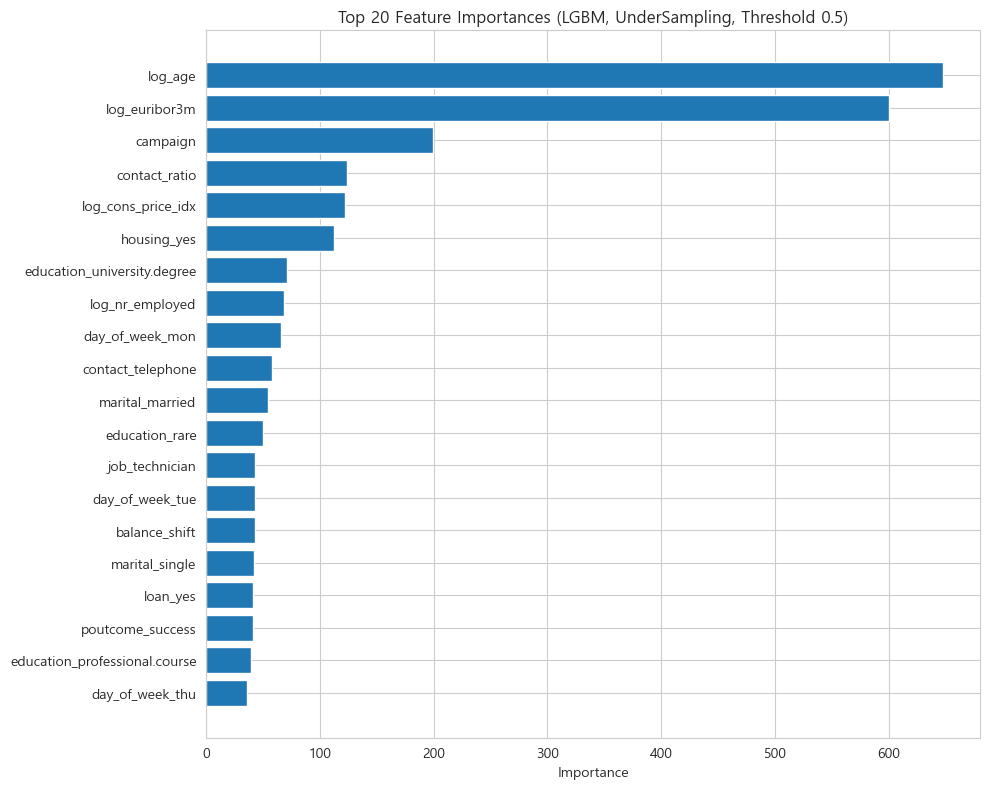

,Feature,Importance
4,log_age,648
8,log_euribor3m,600
1,campaign,199
11,contact_ratio,124
7,log_cons_price_idx,122
31,housing_yes,112
29,education_university.degree,71
9,log_nr_employed,68
44,day_of_week_mon,66
34,contact_telephone,58


In [64]:
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 예시: 특성 중요도 추출 및 정렬
feature_importances = pipeline_under.named_steps['model'].feature_importances_
feature_names = X.columns  # 기존 전처리된 X 사용

# 데이터프레임으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 상위 20개만 시각화
top_n = 20
top_features = importance_df.head(top_n)

# 시각화
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (LGBM, UnderSampling, Threshold 0.5)")
plt.tight_layout()
plt.show()

# 표로도 출력
top_features

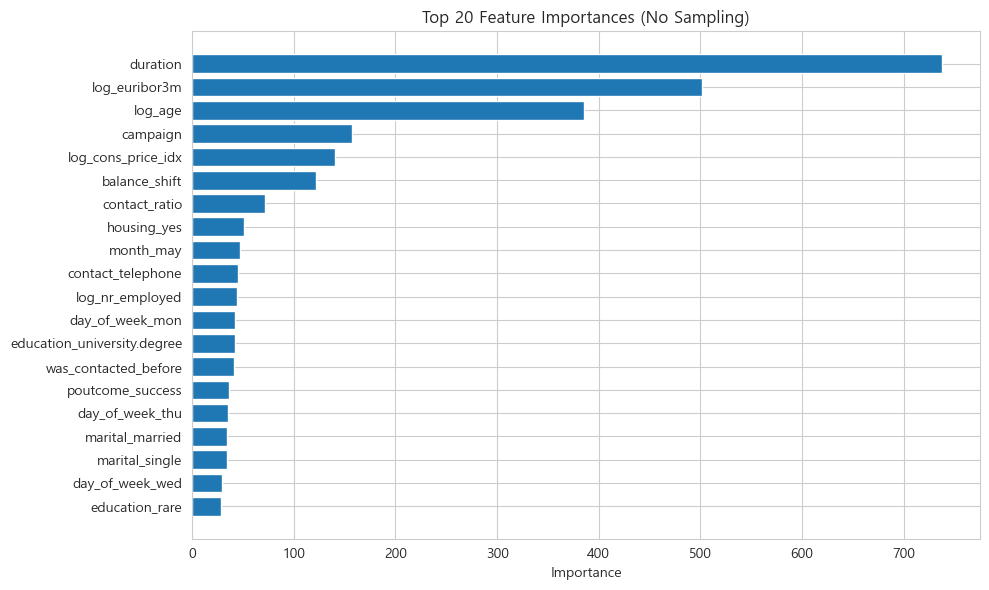

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# 최종 모델: 샘플링 없음
final_model = pipe_none.named_steps['model']
final_features = X.columns

# 중요도 정렬
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 상위 20개만 시각화
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (No Sampling)")
plt.barh(range(20), importances[indices[:20]][::-1])
plt.yticks(range(20), [final_features[i] for i in indices[:20]][::-1])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 6. 결론

두 가지 모델의 Feature Importance 상위 20개 항목 비교 및 duration 변수의 영향력 분석

---

모델 A: `duration` **제외** (언더샘플링 적용)

- `log_age`, `log_euribor3m` 두 변수가 **가장 중요한 설명 변수**로 도출됨.
- 그 외에는 `campaign`, `contact_ratio`, `log_cons_price_idx` 등 **마케팅 행동 및 외부 경제 변수들**이 고르게 분포.
- `housing_yes`, `education_university.degree` 등도 **비교적 높은 기여도**를 보임.

→ **실전 예측 모델**로서 유용하며, **사전 정보 기반 전략 수립에 적합**.

---

모델 B: `duration` **포함** (노샘플링 적용)

- `duration` 변수가 **압도적 1순위**로 등장.  
  이는 실제 **콜 응답 시간과 전환 간 상관이 높기 때문**.
- `log_euribor3m`, `log_age`, `campaign` 순으로 뒤를 이음.
- `month_may`, `contact_telephone` 등 **전환 맥락의 결과 중심 변수**가 상위에 포함됨.

→ **사후 분석용** 또는 **완전한 이력 기반 시뮬레이션에 유리**.

---

모델 간 비교 요약

| **비교 항목** | **모델 A (`duration` 없음)**                 | **모델 B (`duration` 포함)**                 |
|--------------|---------------------------------------------|---------------------------------------------|
| **주요 변수** | `log_age`, `log_euribor3m`, `campaign` 등     | `duration`, `log_euribor3m`, `log_age` 등    |
| **목적**     | 실전 예측, 마케팅 타겟팅용                      | 캠페인 회고, 전환 요인 분석용                    |
| **전략 제안** | 사전 정보 기반 리드 타겟팅                      | 콜 시간 최적화, 응답 지속 유도 등                 |

---

인사이트 요약

- `duration`은 **전환에 대한 강한 설명력**을 가지지만, **사전 정보로는 활용 불가**하므로 **예측 모델에서는 제외**하는 것이 타당.
- 그러나 **캠페인 후반 성과 분석 및 전략 보완**을 위해서는 **포함 모델의 분석이 유의미**하며,  
  **두 버전 모두 병행 활용이 권장됨**.
